In [67]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.legend_handler import HandlerTuple
import subprocess
import os

matplotlib.rcParams.update({"axes.grid": True, "font.size": 15})
# matplotlib.rcParams.keys()

In [68]:
def readmetadata(fname):
    on = False
    lines = ""
    with open(fname) as file:
        for line in file:
            idx = line.find("Hamiltonian")
            if idx != -1:
                on = True
            if on and line.find("--") == -1 and line.find("[") == -1:
                lines += line
            idx = line.find("Called")
            if idx != -1:
                on = False
                break
    meta_dict = {"Description": lines}
    return meta_dict

def valErr_format(val, err):
    if err > 0:
        place = int(np.floor(np.log10(err)))
        
        # Handle the edge case where rounding bumps it to the next power of 10 (e.g., 0.98 -> 1.0)
        if round(err, -place) >= 10**(place + 1):
            place += 1    
        decimals = max(0, -place)
        err_rounded = round(err, -place)
        val_rounded = round(val, -place)
    else:
        decimals = 3  # Fallback if error is exactly 0
        err_rounded = 0.0
        val_rounded = val

    return f"{val_rounded:.{decimals}f} ± {err_rounded:.{decimals}f}"

def trueRound(val, dec):
    secondToLastFig = np.floor(val * 10**(dec+1)) % 10
    truncated = np.floor(val * 10**dec)
    for i in range(len(val)):
        if secondToLastFig[i] >= 5:
            truncated[i] += 1
    return truncated / 10**dec


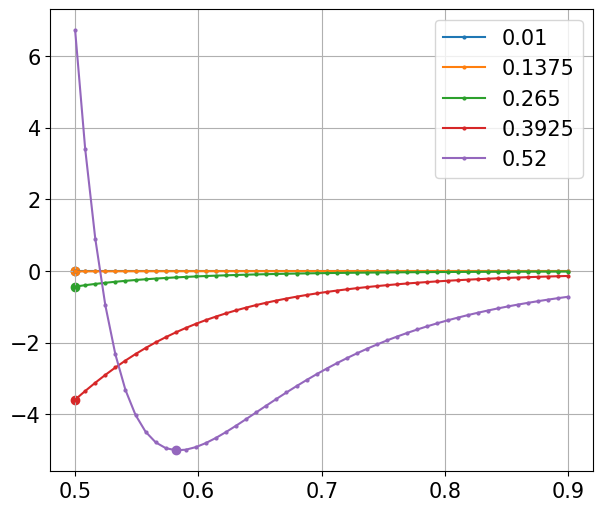

In [69]:
fig = plt.figure(figsize=(7,6))
gs = fig.add_gridspec(1,1)
ax = fig.add_subplot(gs[0,0])

enEps = 5
omega = 1
r = np.linspace(0.5, stop=0.9)
sigma = np.linspace(start=0.01, stop=0.52, num=5)
for i in range(sigma.size):
    var = (sigma[i] / r)**6
    V = 4 * enEps * var * (var - 1)
    rmin = np.argmin(V)
    ax.errorbar(r, V, marker='.', markersize=4, label=sigma[i])
    ax.scatter(r[rmin], V[rmin])
ax.legend()

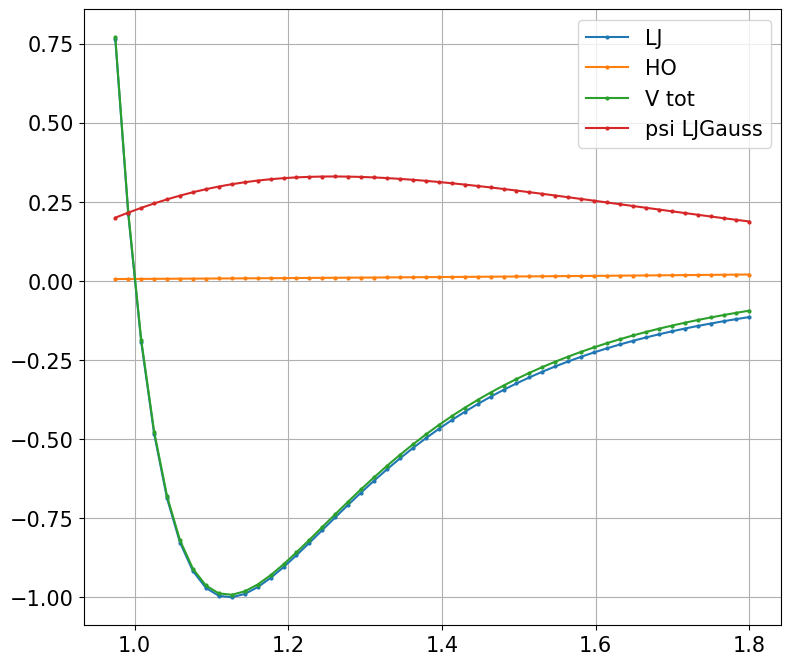

In [70]:
fig = plt.figure(figsize=(9,8))
gs = fig.add_gridspec(1,1)
ax = fig.add_subplot(gs[0,0])

enEps = 1
omega = 1
r = np.linspace(0.975, stop=1.8)
sigma = 1
var = (sigma / r)**6
LJ = 4 * enEps * var * (var - 1)
omega = 0.111803
HO = 0.5 * omega**2 * r**2
V = LJ + HO
alpha = 2
LJGauss = np.exp(-1/(2 * alpha) * r**2 - 0.5 * (sigma/r)**5)
# rmin = np.argmin(V)
ax.errorbar(r, LJ, marker='.', markersize=4, label="LJ")
ax.errorbar(r, HO, marker='.', markersize=4, label="HO")
ax.errorbar(r, V, marker='.', markersize=4, label="V tot")
ax.errorbar(r, LJGauss**2, marker='.', markersize=4, label="psi LJGauss")
# ax.scatter(r[rmin], V[rmin])
ax.legend()

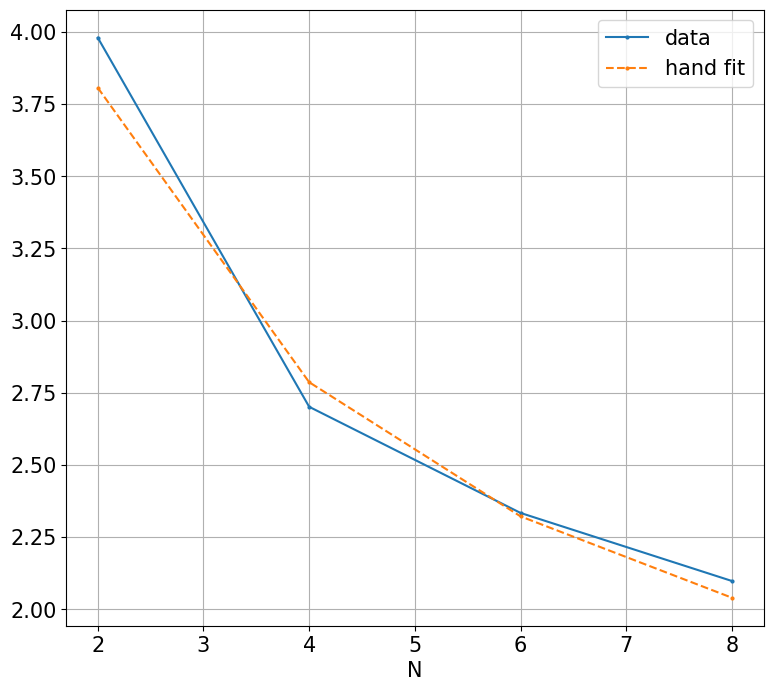

In [71]:
fig = plt.figure(figsize=(9,8))
gs = fig.add_gridspec(1,1)
ax = fig.add_subplot(gs[0,0])

N = np.array([2,4,6,8])
alpha = np.array([3.98009743, 2.70142433, 2.33365906, 2.09789077])
ax.errorbar(N, alpha, marker='.', markersize=4, label="data")
ax.errorbar(N, 5.2/N**(0.45), marker='.', markersize=4, ls='--', label="hand fit")
ax.set_xlabel("N")
ax.legend()

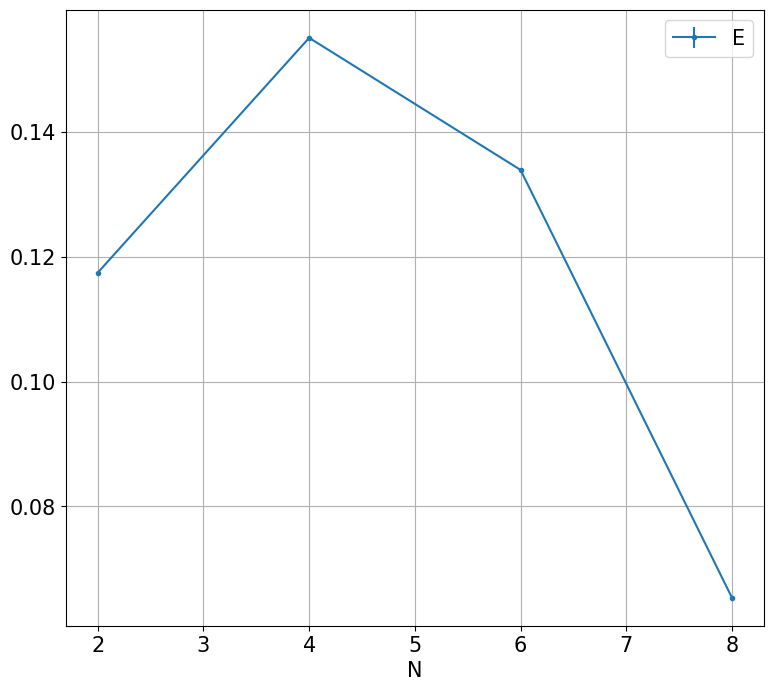

In [72]:
fig = plt.figure(figsize=(9,8))
gs = fig.add_gridspec(1,1)
ax = fig.add_subplot(gs[0,0])

N = np.array([2,4,6,8])

E = np.array([1.174467088e-01, 1.550433449e-01, 1.338948238e-1, 6.541837939e-02])
dE = np.array([1.112297955e-05, 1.870194814e-05, 8.325633413e-5, 3.063435401e-05])

ax.errorbar(N, E, dE, marker='.', markersize=6, label="E")
ax.set_xlabel("N")
ax.legend()

In [73]:
sigma = 1
alpha = np.array([1, 0.4, 0.05])
beta1 = (16/5 * alpha)**0.1 * sigma
print(beta1)

[1.12334976 1.02499323 0.83255321]


In [74]:
lsp = np.array([1.111 + i * 0.0001 for i in range(30)])
print(lsp)
res = trueRound(lsp,3)
print(res)

[1.111  1.1111 1.1112 1.1113 1.1114 1.1115 1.1116 1.1117 1.1118 1.1119
 1.112  1.1121 1.1122 1.1123 1.1124 1.1125 1.1126 1.1127 1.1128 1.1129
 1.113  1.1131 1.1132 1.1133 1.1134 1.1135 1.1136 1.1137 1.1138 1.1139]
[1.111 1.111 1.111 1.111 1.111 1.112 1.112 1.112 1.112 1.112 1.112 1.112
 1.112 1.112 1.112 1.113 1.113 1.113 1.113 1.113 1.113 1.113 1.113 1.113
 1.113 1.114 1.114 1.114 1.114 1.114]


In [75]:
omega = np.array([np.sqrt(0.2)/4, np.sqrt(0.2)/16])
print(f"omega = {omega}")
omega = np.round(omega, 6)
print(f"omega = {omega}")
E_0 = 3/2 * omega * np.sqrt(0.2)
print(f"E_0 = {[f"{e:.11f}" for e in E_0]}")
allE = np.zeros((4, 2))
for i in range(4):
    N = 2 * (i+1)
    allE[i] = trueRound(E_0 * N, 10)
    print(f"N={N} : {[f"{e:.10f}" for e in allE[i]]}")

omega = [0.1118034  0.02795085]
omega = [0.111803 0.027951]
E_0 = ['0.07499973243', '0.01875010081']
N=2 : ['0.1499994649', '0.0375002016']
N=4 : ['0.2999989297', '0.0750004032']
N=6 : ['0.4499983946', '0.1125006049']
N=8 : ['0.5999978594', '0.1500008065']


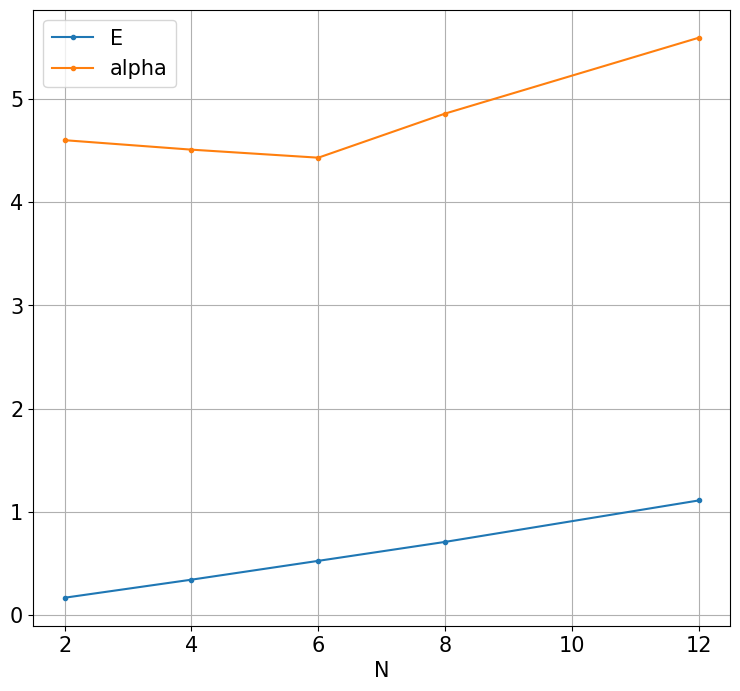

In [76]:
fig = plt.figure(figsize=(9,8))
gs = fig.add_gridspec(1,1)
ax = fig.add_subplot(gs[0,0])

N = [2, 4, 6, 8, 12]
alpha = [4.6000, 4.5084, 4.4306, 4.8579, 5.5925]
energy = [0.16871, 0.34360, 0.5259, 0.7094, 1.1109]

ax.errorbar(N, energy, marker='.', markersize=6, label="E")
ax.errorbar(N, alpha, marker='.', markersize=6, label="alpha")
ax.set_xlabel("N")
ax.legend()

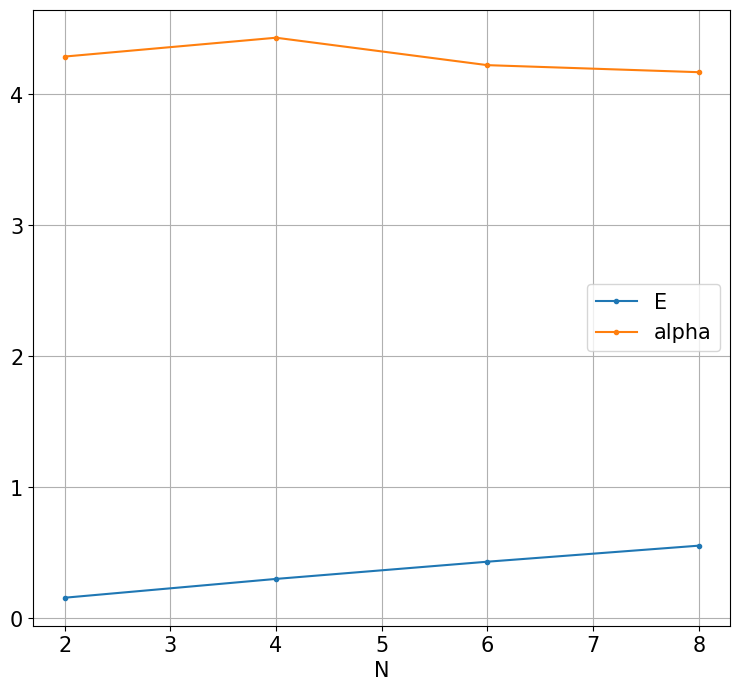

In [77]:
fig = plt.figure(figsize=(9,8))
gs = fig.add_gridspec(1,1)
ax = fig.add_subplot(gs[0,0])

N = np.array([2, 4, 6, 8])
alpha = np.array([4.2884, 4.4322, 4.2228, 4.1691])
energy = np.array([0.157485, 0.30107, 0.43246, 0.5549])

ax.errorbar(N, energy, marker='.', markersize=6, label="E")
ax.errorbar(N, alpha, marker='.', markersize=6, label="alpha")
ax.set_xlabel("N")
ax.legend()

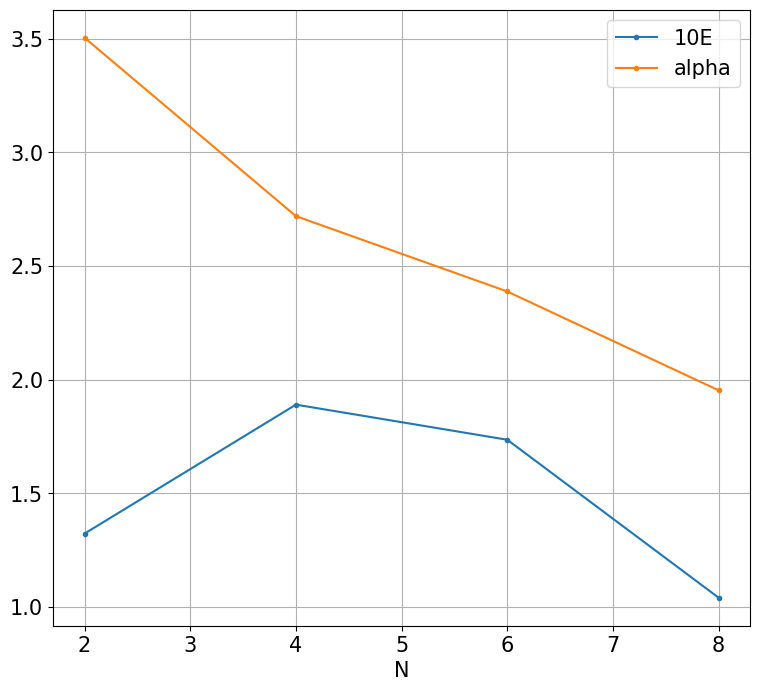

In [78]:
fig = plt.figure(figsize=(9,8))
gs = fig.add_gridspec(1,1)
ax = fig.add_subplot(gs[0,0])

N = np.array([2, 4, 6, 8])
alpha = np.array([3.5043, 2.7195, 2.3881, 1.9532])
energy = np.array([0.132306, 0.18903, 0.17359, 0.1041])

ax.errorbar(N, energy*10, marker='.', markersize=6, label="10E")
ax.errorbar(N, alpha, marker='.', markersize=6, label="alpha")
ax.set_xlabel("N")
ax.legend()

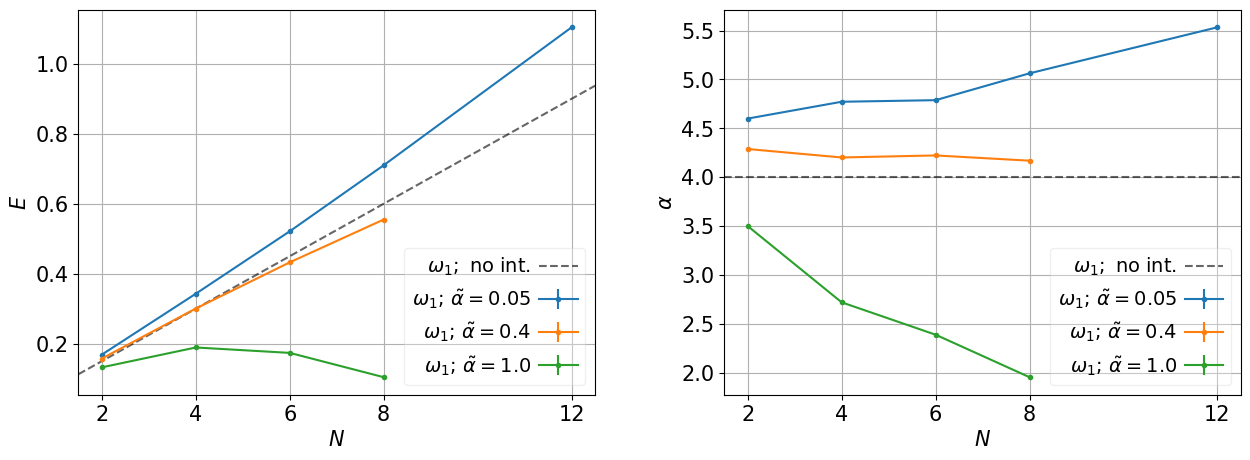

In [79]:
Nspace = np.linspace(2,8, endpoint=True)
omega = np.array([np.sqrt(0.2)/4, np.sqrt(0.2)/16])
omega = np.round(omega, 6)
E_0 = 3/2 * omega * np.sqrt(0.2)

fig = plt.figure(figsize=(15,5))
gs = fig.add_gridspec(1,2, wspace=0.25)
fig.tight_layout()
ax = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])

ax.axline([Nspace[0], Nspace[0] * E_0[0]], [Nspace[-1], Nspace[-1] * E_0[0]], ls='--', label=r"$\omega_1;$ no int.", color="black", alpha=0.6)
ax1.axhline(4, ls='--', label=r"$\omega_1;$ no int.", color="black", alpha=0.6)
df = pd.read_csv("reportResults/interacting_results_A.csv", na_values="--")
df.columns = [c.replace('#', '').strip() for c in df.columns]
grouped = df.groupby("tildeAlpha")
for i, group in grouped:
    block_indices = np.arange(len(group))
    N = group["N"].values
    E = group["E"].values
    alpha = group["alpha"].values
    err = group["err"].values
    
    ax.errorbar(N, E, err, marker='.', markersize=6, label=r"$\omega_1;\,\tilde{\alpha} = "rf"{i}"r"$")
    ax1.errorbar(N, alpha, 1e-4 * alpha, marker='.', markersize=6, label=r"$\omega_1;\,\tilde{\alpha} = "rf"{i}"r"$")


ax.set_xlabel(r"$N$")
ax.set_ylabel(r"$E$")
# ax.set_ylim(-0.25, 0.85)
ax.legend(ncols=1, columnspacing = 0.8, handletextpad=0.4, markerfirst=False, framealpha=0.3, fontsize=14, loc=4)
ax.set_xticks([2,4,6,8,12], ["2","4","6","8", "12"])
ax1.set_xlabel(r"$N$")
ax1.set_ylabel(r"$\alpha$")
ax1.set_xticks([2,4,6,8,12], ["2","4","6","8","12"])
ax1.legend(ncols=1, columnspacing = 0.8, handletextpad=0.4, markerfirst=False, framealpha=0.3, fontsize=14, loc=4)
fig.savefig("reportResults/omega1_energy_alpha.png", dpi=300, transparent=True)

$\omega_1;\,\tilde{\alpha} = 0.05$ mean beta_AB = 0.9572200000000001 +- 0.006188014221056707
$\omega_1;\,\tilde{\alpha} = 0.4$ mean beta_AB = 1.0706 +- 0.0024829418035870175
$\omega_1;\,\tilde{\alpha} = 1.0$ mean beta_AB = 1.12425 +- 0.0029884151318048152


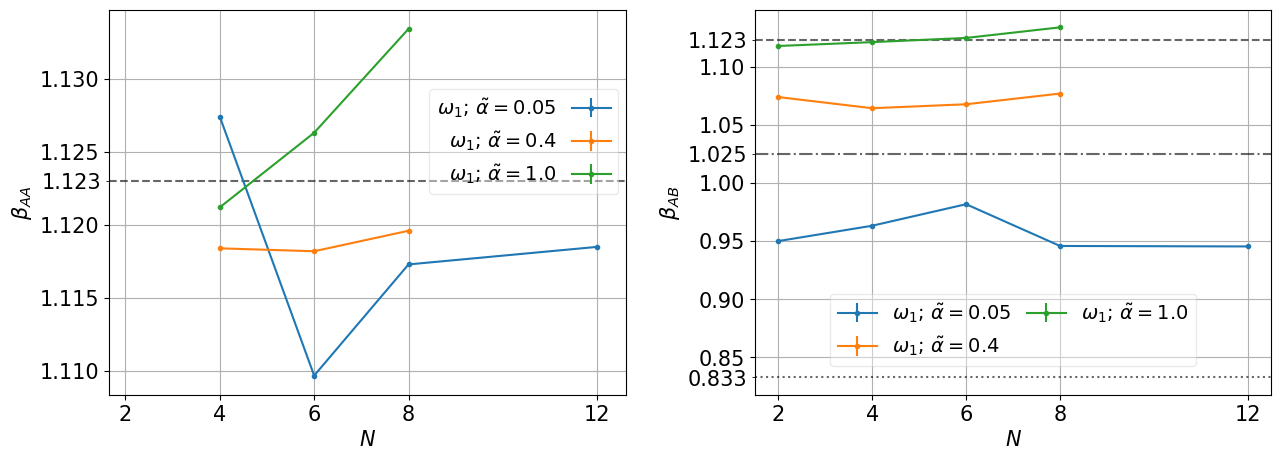

In [80]:
fig = plt.figure(figsize=(15,5))
gs = fig.add_gridspec(1,2, wspace=0.25)
fig.tight_layout()
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])

ax1.axhline(1.123, ls='--', color="black", alpha=0.6)
# ax1.text(2, 1.123 + 5e-4, "1.123")
ax2.axhline(1.123, ls='--', color="black", alpha=0.6)
# ax2.text(2, 1.123 + 5e-4, "1.123")
ax2.axhline(1.025, ls='-.', color="black", alpha=0.6)
# ax2.text(2, 1.025 + 5e-4, "1.025")
ax2.axhline(0.833, ls=':', color="black", alpha=0.6)
# ax2.text(2, 0.833 + 5e-4, "0.833")

df = pd.read_csv("reportResults/interacting_results_A.csv", na_values="--")
df.columns = [c.replace('#', '').strip() for c in df.columns]
grouped = df.groupby("tildeAlpha")
for i, group in grouped:
    block_indices = np.arange(len(group))
    N = group["N"].values
    beta_AA = np.array(group["beta_AA"].values[1:], dtype=float)
    beta_AB = group["beta_AB"].values
    ax1.errorbar(N[1:], beta_AA, 1e-4 * beta_AA, marker='.', markersize=6, label=r"$\omega_1;\,\tilde{\alpha} = "rf"{i}"r"$")
    ax2.errorbar(N, beta_AB, 1e-4 * beta_AB, marker='.', markersize=6, label=r"$\omega_1;\,\tilde{\alpha} = "rf"{i}"r"$")
    print(r"$\omega_1;\,\tilde{\alpha} = "rf"{i}"r"$"f" mean beta_AB = {np.mean(beta_AB)} +- {np.sqrt(np.var(beta_AB) / beta_AB.size)}")

ax1.set_xlabel(r"$N$")
ax1.set_ylabel(r"$\beta_{AA}$")
ax1.set_xlim(1.65, 12.6)
ax1.set_yticks([1.123], ["1.123"], minor=True)
ax1.set_xticks([2,4,6,8,12], ["2","4","6","8","12"])
ax1.legend(ncols=1, columnspacing = 0.8, framealpha=0.4, fontsize=14, loc=1, markerfirst=False, borderaxespad=0.1, bbox_to_anchor=(0.99,0.8))
ax2.set_xlabel(r"$N$")
ax2.set_ylabel(r"$\beta_{AB}$")
ax2.set_yticks([1.123, 1.025, 0.833], ["1.123", "1.025", "0.833"], minor=True)
ax2.set_xticks([2,4,6,8,12], ["2","4","6","8","12"])
handles, labels = ax2.get_legend_handles_labels()
dummy_handle = ax2.scatter([], [], marker='none')
handles.insert(3, dummy_handle)
labels.insert(3, '')
ax2.legend(handles, labels, ncols=2, columnspacing = 0.8, framealpha=0.4, fontsize=14, loc=8, bbox_to_anchor=(0.5,0.05))
fig.savefig("reportResults/omega1_betas.png", dpi=300, transparent=True)

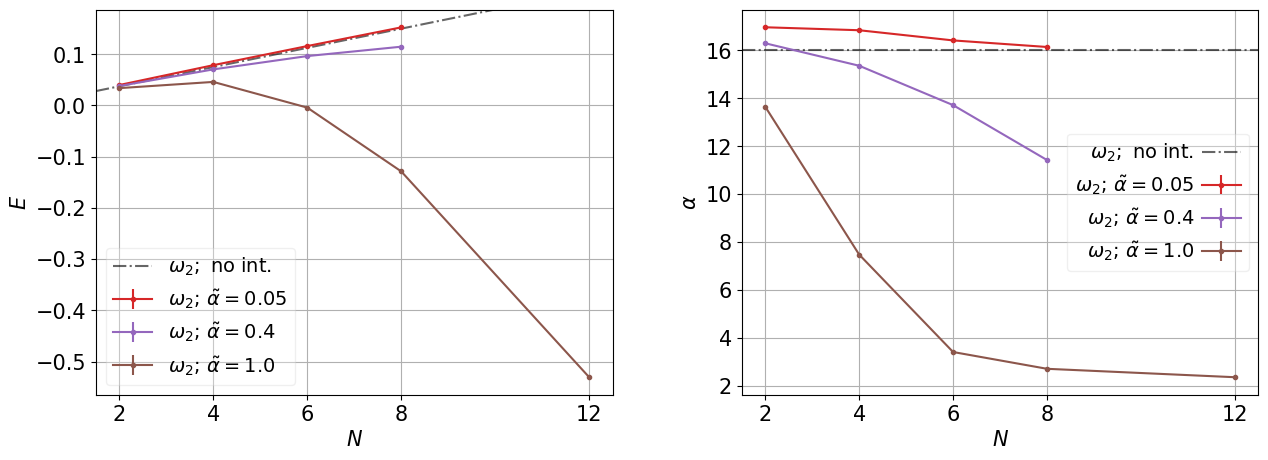

In [81]:
Nspace = np.linspace(2,8, endpoint=True)
omega = np.array([np.sqrt(0.2)/4, np.sqrt(0.2)/16])
omega = np.round(omega, 6)
E_0 = 3/2 * omega * np.sqrt(0.2)

fig = plt.figure(figsize=(15,5))
gs = fig.add_gridspec(1,2, wspace=0.25)
fig.tight_layout()
ax = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])
cmap_colors = matplotlib.colormaps.get_cmap("tab10")
cmap_colors = [cmap_colors.colors[i] for i in range(3, 10)]

ax.axline([Nspace[0], Nspace[0] * E_0[1]], [Nspace[-1], Nspace[-1] * E_0[1]], ls='-.', label=r"$\omega_2;$ no int.", color="black", alpha=0.6)
ax1.axhline(16, ls='-.', label=r"$\omega_2;$ no int.", color="black", alpha=0.6)
df = pd.read_csv("reportResults/interacting_results_B.csv", na_values="--")
df.columns = [c.replace('#', '').strip() for c in df.columns]
grouped = df.groupby("tildeAlpha")
count = 0
for i, group in grouped:
    block_indices = np.arange(len(group))
    N = group["N"].values
    E = group["E"].values
    alpha = group["alpha"].values
    err = group["err"].values
    color = cmap_colors[count]
    count += 1
    
    ax.errorbar(N, E, err, marker='.', markersize=6, label=r"$\omega_2;\,\tilde{\alpha} = "rf"{i}"r"$", c=color)
    ax1.errorbar(N, alpha, 1e-4 * alpha, marker='.', markersize=6, label=r"$\omega_2;\,\tilde{\alpha} = "rf"{i}"r"$", c=color)


ax.set_xlabel(r"$N$")
ax.set_ylabel(r"$E$")
# ax.set_ylim(-0.25, 0.85)
ax.legend(ncols=1, columnspacing = 0.8, framealpha=0.3, fontsize=14, loc=3)
ax.set_xticks([2,4,6,8,12], ["2","4","6","8","12"])
ax1.set_xlabel(r"$N$")
ax1.set_ylabel(r"$\alpha$")
ax1.set_xticks([2,4,6,8,12], ["2","4","6","8","12"])
ax1.legend(ncols=1, columnspacing = 0.8, handletextpad=0.4, markerfirst=False, framealpha=0.3, fontsize=14, loc=7)
fig.savefig("reportResults/omega2_energy_alpha.png", dpi=300, transparent=True)

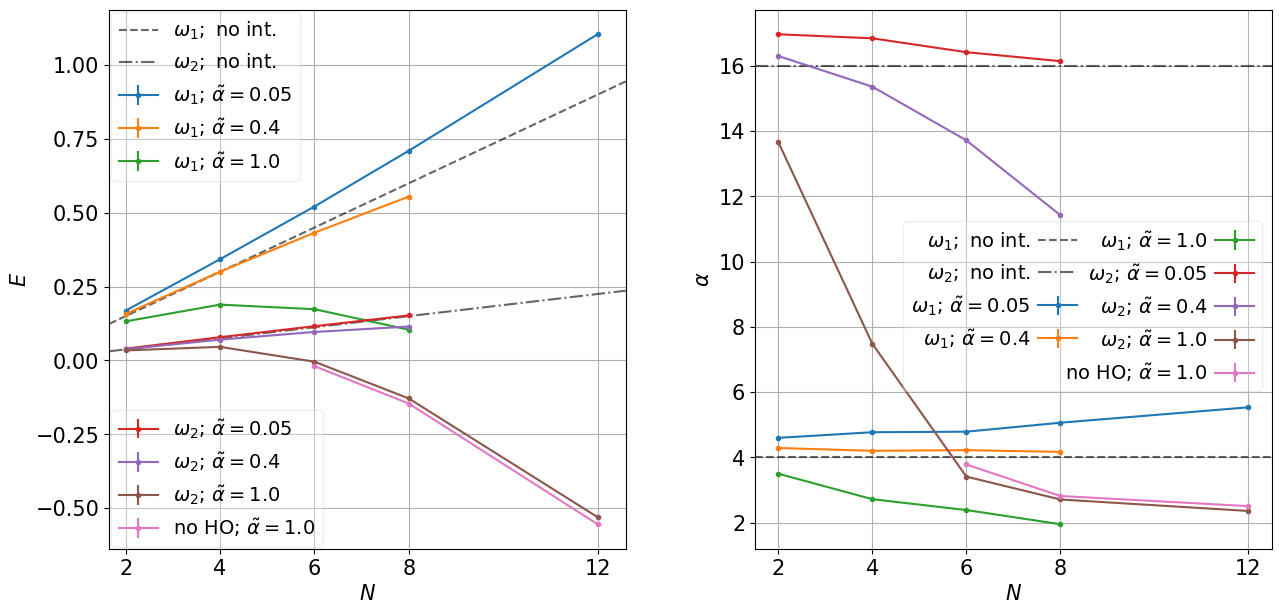

In [82]:
Nspace = np.linspace(2,8, endpoint=True)
omega = np.array([np.sqrt(0.2)/4, np.sqrt(0.2)/16])
omega = np.round(omega, 6)
E_0 = 3/2 * omega * np.sqrt(0.2)

fig = plt.figure(figsize=(15,7))
gs = fig.add_gridspec(1,2, wspace=0.25)
fig.tight_layout()
ax = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])

ax.axline([Nspace[0], Nspace[0] * E_0[0]], [Nspace[-1], Nspace[-1] * E_0[0]], ls='--', label=r"$\omega_1;$ no int.", color="black", alpha=0.6)
ax1.axhline(4, ls='--', label=r"$\omega_1;$ no int.", color="black", alpha=0.6)
df = pd.read_csv("reportResults/interacting_results_A.csv", na_values="--")
df.columns = [c.replace('#', '').strip() for c in df.columns]
grouped = df.groupby("tildeAlpha")
for i, group in grouped:
    block_indices = np.arange(len(group))
    N = group["N"].values
    E = group["E"].values
    alpha = group["alpha"].values
    err = group["err"].values
    
    ax.errorbar(N, E, err, marker='.', markersize=6, label=r"$\omega_1;\,\tilde{\alpha} = "rf"{i}"r"$")
    ax1.errorbar(N, alpha, 1e-4 * alpha, marker='.', markersize=6, label=r"$\omega_1;\,\tilde{\alpha} = "rf"{i}"r"$")

ax.axline([Nspace[0], Nspace[0] * E_0[1]], [Nspace[-1], Nspace[-1] * E_0[1]], ls='-.', label=r"$\omega_2;$ no int.", color="black", alpha=0.6)
ax1.axhline(16, ls='-.', label=r"$\omega_2;$ no int.", color="black", alpha=0.6)
df = pd.read_csv("reportResults/interacting_results_B.csv", na_values="--")
df.columns = [c.replace('#', '').strip() for c in df.columns]
grouped = df.groupby("tildeAlpha")
for i, group in grouped:
    block_indices = np.arange(len(group))
    N = group["N"].values
    E = group["E"].values
    alpha = group["alpha"].values
    err = group["err"].values
    
    ax.errorbar(N, E, err, marker='.', markersize=6, label=r"$\omega_2;\,\tilde{\alpha} = "rf"{i}"r"$")
    ax1.errorbar(N, alpha, 1e-4 * alpha, marker='.', markersize=6, label=r"$\omega_2;\,\tilde{\alpha} = "rf"{i}"r"$")

df = pd.read_csv("reportResults/interacting_results_C.csv", na_values="--")
df.columns = [c.replace('#', '').strip() for c in df.columns]
grouped = df.groupby("tildeAlpha")
for i, group in grouped:
    block_indices = np.arange(len(group))
    N = group["N"].values
    E = group["E"].values
    alpha = group["alpha"].values
    err = group["err"].values
    
    ax.errorbar(N, E, err, marker='.', markersize=6, label=r"no HO$;\,\tilde{\alpha} = "rf"{i}"r"$")
    ax1.errorbar(N, alpha, 1e-4 * alpha, marker='.', markersize=6, label=r"no HO$;\,\tilde{\alpha} = "rf"{i}"r"$")


ax.set_xlabel(r"$N$")
ax.set_ylabel(r"$E$")
ax.set_xlim(1.65, 12.6)
handles, labels = ax.get_legend_handles_labels()
n = len(handles)
leg1 = ax.legend(handles[:n//2+1], labels[:n//2+1], ncols=1, columnspacing=0.8, 
                 framealpha=0.3, fontsize=14, loc=2, markerfirst=True, borderaxespad=0.1)
ax.legend(handles[n//2+1:], labels[n//2+1:], ncols=1, columnspacing=0.8, 
          framealpha=0.3, fontsize=14, loc=3, markerfirst=True, borderaxespad=0.1)
ax.add_artist(leg1)
ax.set_xticks([2,4,6,8,12], ["2","4","6","8","12"])
ax1.set_xlabel(r"$N$")
ax1.set_ylabel(r"$\alpha$")
ax1.set_xticks([2,4,6,8,12], ["2","4","6","8","12"])
handles, labels = ax1.get_legend_handles_labels()
dummy_handle = ax1.scatter([], [], marker='none')
handles.insert(4, dummy_handle)
labels.insert(4, '')
ax1.legend(handles, labels, ncols=2, columnspacing = -0.6, handletextpad=0.4, markerfirst=False, framealpha=0.3, fontsize=14, loc=7, bbox_to_anchor=(1, 0.45))
fig.savefig("reportResults/final_energy_alpha.png", dpi=300, transparent=True)

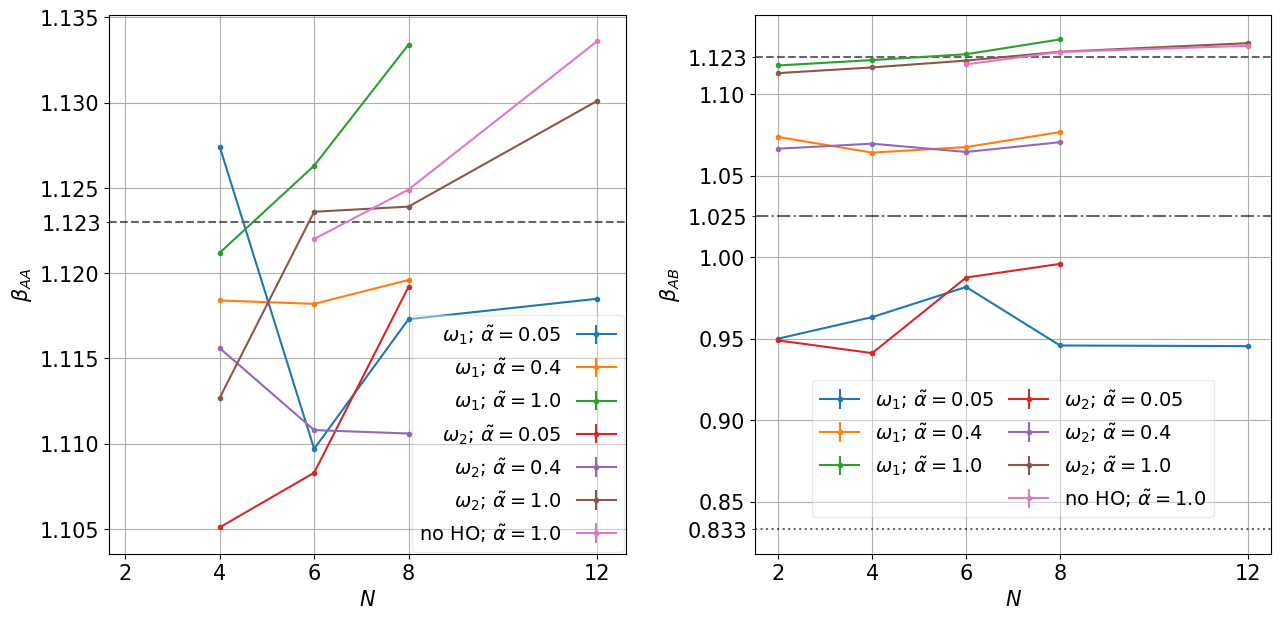

In [83]:
fig = plt.figure(figsize=(15,7))
gs = fig.add_gridspec(1,2, wspace=0.25)
fig.tight_layout()
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])

ax1.axhline(1.123, ls='--', color="black", alpha=0.6)
# ax1.text(2, 1.123 + 5e-4, "1.123")
ax2.axhline(1.123, ls='--', color="black", alpha=0.6)
# ax2.text(2, 1.123 + 5e-4, "1.123")
ax2.axhline(1.025, ls='-.', color="black", alpha=0.6)
# ax2.text(2, 1.025 + 5e-4, "1.025")
ax2.axhline(0.833, ls=':', color="black", alpha=0.6)
# ax2.text(2, 0.833 + 5e-4, "0.833")


df = pd.read_csv("reportResults/interacting_results_A.csv", na_values="--")
df.columns = [c.replace('#', '').strip() for c in df.columns]
grouped = df.groupby("tildeAlpha")
for i, group in grouped:
    block_indices = np.arange(len(group))
    N = group["N"].values
    beta_AA = np.array(group["beta_AA"].values[1:], dtype=float)
    beta_AB = group["beta_AB"].values
    ax1.errorbar(N[1:], beta_AA, 1e-4 * beta_AA, marker='.', markersize=6, label=r"$\omega_1;\,\tilde{\alpha} = "rf"{i}"r"$")
    ax2.errorbar(N, beta_AB, 1e-4 * beta_AB, marker='.', markersize=6, label=r"$\omega_1;\,\tilde{\alpha} = "rf"{i}"r"$")

df = pd.read_csv("reportResults/interacting_results_B.csv", na_values="--")
df.columns = [c.replace('#', '').strip() for c in df.columns]
grouped = df.groupby("tildeAlpha")
for i, group in grouped:
    block_indices = np.arange(len(group))
    N = group["N"].values
    beta_AA = np.array(group["beta_AA"].values[1:], dtype=float)
    beta_AB = group["beta_AB"].values
    
    ax1.errorbar(N[1:], beta_AA, 1e-4 * beta_AA, marker='.', markersize=6, label=r"$\omega_2;\,\tilde{\alpha} = "rf"{i}"r"$")
    ax2.errorbar(N, beta_AB, 1e-4 * beta_AB, marker='.', markersize=6, label=r"$\omega_2;\,\tilde{\alpha} = "rf"{i}"r"$")

df = pd.read_csv("reportResults/interacting_results_C.csv", na_values="--")
df.columns = [c.replace('#', '').strip() for c in df.columns]
grouped = df.groupby("tildeAlpha")
for i, group in grouped:
    block_indices = np.arange(len(group))
    N = group["N"].values

    beta_AA = np.array(group["beta_AA"].values, dtype=float)
    beta_AB = group["beta_AB"].values

    ax1.errorbar(N, beta_AA, 1e-4 * beta_AA, marker='.', markersize=6, label=r"no HO$;\,\tilde{\alpha} = "rf"{i}"r"$")
    ax2.errorbar(N, beta_AB, 1e-4 * beta_AB, marker='.', markersize=6, label=r"no HO$;\,\tilde{\alpha} = "rf"{i}"r"$")


ax1.set_xlabel(r"$N$")
ax1.set_ylabel(r"$\beta_{AA}$")
ax1.set_xlim(1.65, 12.6)
ax1.set_yticks([1.123], ["1.123"], minor=True)
ax1.set_xticks([2,4,6,8,12], ["2","4","6","8","12"])
ax1.legend(ncols=1, columnspacing = 0.8, framealpha=0.4, fontsize=14, loc=4, markerfirst=False, borderaxespad=0.1)
ax2.set_xlabel(r"$N$")
ax2.set_ylabel(r"$\beta_{AB}$")
ax2.set_yticks([1.123, 1.025, 0.833], ["1.123", "1.025", "0.833"], minor=True)
ax2.set_xticks([2,4,6,8,12], ["2","4","6","8","12"])
handles, labels = ax2.get_legend_handles_labels()
dummy_handle = ax2.scatter([], [], marker='none')
handles.insert(3, dummy_handle)
labels.insert(3, '')
ax2.legend(handles, labels, ncols=2, columnspacing = 0.8, framealpha=0.4, fontsize=14, loc=8, bbox_to_anchor=(0.5,0.05))
fig.savefig("reportResults/final_betas.png", dpi=300, transparent=True)

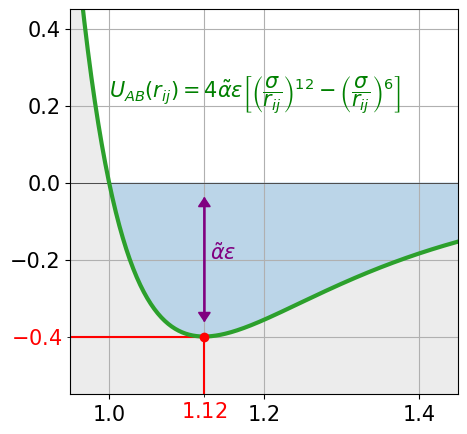

In [84]:
fig = plt.figure(figsize=(5,5))
gs = fig.add_gridspec(1,1)
ax = fig.add_subplot(gs[0,0])

enEps = 1
sigma = 1
r = np.linspace(0.95, stop=1.55, num=400)
alphaTilde = 0.4
temp = (sigma / r)**6
LJ = 4 * enEps * alphaTilde * temp * (temp - 1)
minidx = np.argmin(LJ)
label = r"$U_{AB}(r_{ij}) = 4\tilde{\alpha}\epsilon\left[\left(\dfrac{\sigma}{r_{ij}}\right)^{12} - \left(\dfrac{\sigma}{r_{ij}}\right)^{6}\right]$"
ax.errorbar(r, LJ, marker='none', markersize=4, c="tab:green", lw=3)
ax.text(1, 0.22, s=label, color="green")
ax.scatter(r[minidx], LJ[minidx], c="red", zorder=4)
# ax.axvline(r[rmin], ymin=-0.5, ymax=-0.4, c="red")
ax.grid(visible=True, which="both")
ax.set_yticks([-0.2, 0.0, 0.2, 0.4], minor=False)
ax.set_yticks([LJ[minidx]], [rf"${LJ[minidx]:.1f}$"], minor=True, color="red")
ax.plot(r, np.zeros(r.size), c="black", lw=0.4)
ax.plot([0.95, r[minidx]], [LJ[minidx], LJ[minidx]], color="red")
ax.plot([r[minidx], r[minidx]], [-0.55, LJ[minidx]], color="red")
ax.set_xticks([r[minidx]], [rf"${r[minidx]:.2f}$"], minor=True, color="red")
ax.set_xticks([1.0, 1.2, 1.4], minor=False)
ax.arrow(r[minidx], LJ[minidx]*0.9, 0, -LJ[minidx]*0.8, length_includes_head=True, color="purple", head_width = 0.015, zorder=10)
ax.arrow(r[minidx], LJ[minidx]*0.1, 0, LJ[minidx]*0.8, length_includes_head=True, color="purple", head_width = 0.015, zorder=10)
ax.text(1.13, -0.2, r"$\tilde{\alpha}\epsilon$", color="purple", zorder=10)
ax.fill_between(r[LJ<=0], LJ[LJ<=0], np.zeros(r[LJ<=0].size), alpha=0.3)
ax.fill_between(r, -np.ones(r.size), LJ, alpha=0.15, color="gray")
# ax.minorticks_on()
ax.set_ylim(-0.55,0.45)
ax.set_xlim(0.95, right=1.45)
# ax.legend()
fig.savefig("beamerFigs/analytical_predictions_LJ", dpi=300, transparent=True)

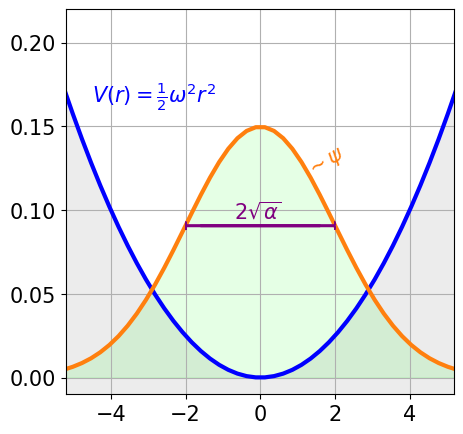

In [85]:
fig = plt.figure(figsize=(5,5))
gs = fig.add_gridspec(1,1)
ax = fig.add_subplot(gs[0,0])

omega = 0.111803
aho = 2
r = np.linspace(-6, 6)
V = 0.5 * omega**2 * r**2
prefactor = (1/(np.pi * aho**2))**(3/4)
# prefactor = (1/(np.pi * aho**2))**(1/4)
# prefactor = 1
wf = prefactor * np.exp(-r**2/(2 * aho**2))
label = r"$V(r) = \frac{1}{2}\omega^2r^2$"
ax.errorbar(r, V, marker='none', markersize=4, c="blue", lw=3)
ax.errorbar(r, wf, marker='none', markersize=4, c="tab:orange", lw=3)
# ax.errorbar(r, wf**2, marker='none', markersize=4, c="gray", lw=3)
ax.text(-4.5, np.max(wf)*1.1, s=label, color="blue")

ax.arrow(-aho*0.8, np.max(wf) * np.exp(-0.5), 2*aho*0.9, 0, length_includes_head=True, color="purple", head_width = 0.005, zorder=10)
ax.arrow(aho*0.8, np.max(wf) * np.exp(-0.5), -2*aho*0.9, 0, length_includes_head=True, color="purple", head_width = 0.005, zorder=10)
ax.text(-0.7, np.max(wf) * np.exp(-0.45), r"$2\sqrt{\alpha}$", color="purple", zorder=10)
ax.text(1.13, 0.12, r"$\sim\psi$", color="tab:orange", zorder=10, rotation=30)
# ax.text(-0.1, 0.025, r"$\sim|\psi|^2$", color="gray", zorder=10, rotation=30)
# ax.fill_between(r, V, 100 * np.ones(r.size), alpha=0.25, color="pink")
ax.fill_between(r, -np.ones(r.size), V, alpha=0.15, color="gray")
ax.fill_between(r, np.zeros(r.size), wf, alpha=0.1, color="lime")
# ax.minorticks_on()
ax.set_ylim(-0.01, 0.22)
ax.set_xlim(-5.2, 5.175)
# ax.legend()
fig.savefig("beamerFigs/analytical_predictions_HO", dpi=300, transparent=True)

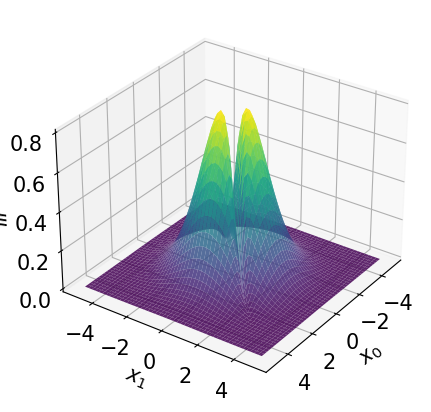

In [ ]:
fig = plt.figure(figsize=(5,5))
gs = fig.add_gridspec(1,1)
ax = fig.add_subplot(gs[0,0], projection='3d')

r0 = np.linspace(-5, 5)
r1 = np.linspace(-5, 5)
R0, R1 = np.meshgrid(r0, r1)
alpha=4
beta=1.12
wf = np.exp(-0.5 * (R0**2 + R1**2)/alpha - 0.5 * (beta/(np.abs(R0 - R1) + 1))**5)
norm = mcolors.PowerNorm(gamma=0.5, vmin=np.min(energy), vmax=np.max(energy))
ax.plot_surface(R0, R1, wf**2, alpha=0.85, cmap='viridis')
ax.set_zlim(0, 0.8)

ax.set_xlabel(r"$x_0$")
ax.set_ylabel(r"$x_1$")
ax.set_zlabel(r"$\psi$")
ax.view_init(elev=30, azim=35)
fig.savefig("beamerFigs/wavefunction_prototype", dpi=300, transparent=True)